Enter your WRDS username [your_wrds_username]: wending24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\19387\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


C:\Users\19387\AppData\Local\Temp\ipykernel_2552\1584542617.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(all_dfs, ignore_index=True)


=== Descriptive Statistics ===
                                date   permno         prc       ret  \
count                           1258   1258.0      1258.0    1258.0   
mean   2022-07-01 15:39:46.645468928  14593.0  187.204277  0.001199   
min              2020-01-02 00:00:00  14593.0      106.84 -0.128647   
25%              2021-04-02 00:00:00  14593.0      144.81 -0.008424   
50%              2022-06-30 12:00:00  14593.0  169.619995   0.00121   
75%              2023-10-01 06:00:00  14593.0     195.885  0.012072   
max              2024-12-31 00:00:00  14593.0      506.09  0.119808   
std                              NaN      0.0   68.444074  0.019957   

                   vol       price  
count           1258.0      1258.0  
mean   73461694.475358  187.204277  
min         20012702.0      106.84  
25%        48594666.25      144.81  
50%         65990118.0  169.619995  
75%         88989374.5     195.885  
max        331572938.0      506.09  
std    36554268.603146   68.44407

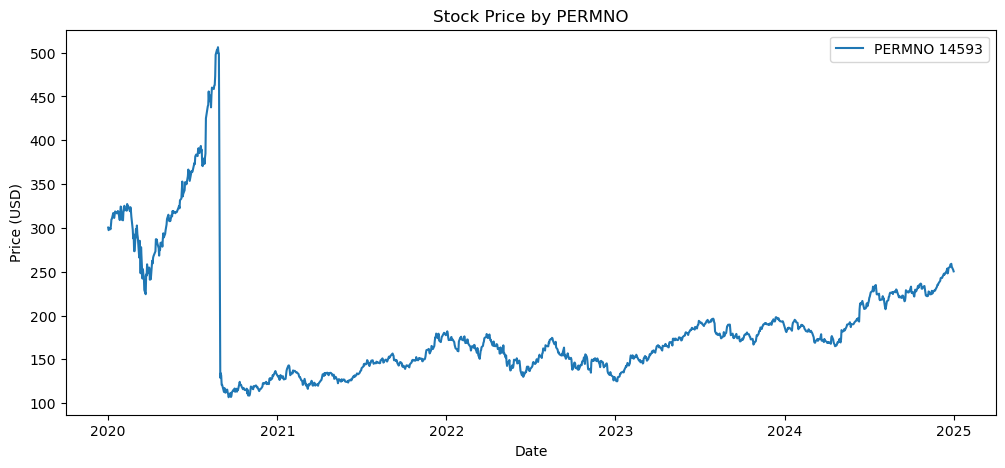

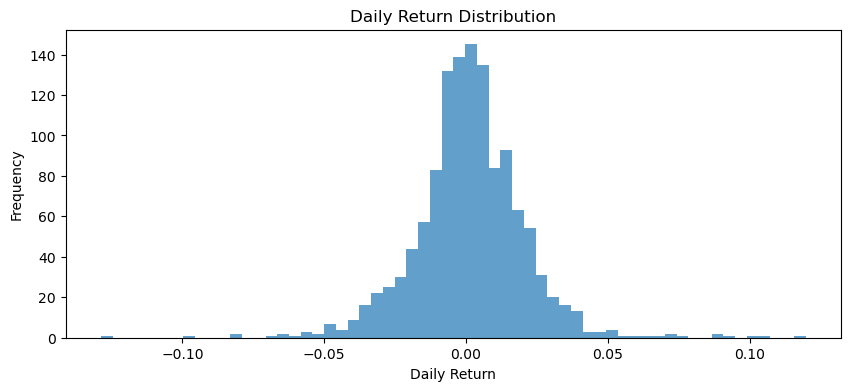

In [1]:
# WRDS Stock Data Analysis
# Data Source: CRSP Daily Stock File (dsf) from WRDS
# This script requires a valid WRDS account

import wrds
import pandas as pd
import matplotlib.pyplot as plt

# Connect to WRDS database
db = wrds.Connection(wrds_username="your_wrds_username")

# Define parameters
permno_list = [14593, 10078]
start_date = "2020-01-01"
end_date = "2024-12-31"

# Fetch data for each stock
all_dfs = []
for permno in permno_list:
    query = f"""
        SELECT date, permno, prc, ret, vol
        FROM crsp.dsf
        WHERE permno = {permno}
        AND date BETWEEN '{start_date}' AND '{end_date}'
    """
    df = db.raw_sql(query)
    all_dfs.append(df)

# Close WRDS connection
db.close()

# Combine data from multiple stocks
df = pd.concat(all_dfs, ignore_index=True)

# Convert date to datetime format
df["date"] = pd.to_datetime(df["date"])

# Clean price (CRSP uses negative signs; take absolute value)
df["price"] = df["prc"].abs()

# Remove rows with missing values
df = df.dropna()

# Show descriptive statistics
print("=== Descriptive Statistics ===")
print(df.describe())

# Plot stock price trend
plt.figure(figsize=(12, 5))
for pno in df['permno'].unique():
    sub = df[df['permno'] == pno]
    plt.plot(sub["date"], sub["price"], label=f"PERMNO {pno}")
plt.title("Stock Price by PERMNO")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

# Plot return distribution
plt.figure(figsize=(10, 4))
plt.hist(df["ret"], bins=60, alpha=0.7)
plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()